# In-Context Learning: Thinking vs Non-Thinking (qwen3:0.6b y qwen3:1.7b)

En este notebook evaluo el rendimiento de ICL (In-Context Learning) para atribucion de autoria,
comparando dos modelos (0.6b y 1.7b) en dos modos cada uno: standard (sin thinking) vs thinking (con Chain-of-Thought + contexto extendido).

## 0. Setup e Imports

In [ ]:
# Imports necesarios para el experimento ICL (In-Context Learning)
from pathlib import Path
import json
import datetime
import requests  # Para comunicarme con Ollama via API REST
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split  # Muestreo estratificado del validation set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tqdm.auto import tqdm  # Barra de progreso para loops largos
import warnings
warnings.filterwarnings('ignore')

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_colwidth', 120)  # Limito ancho de columnas para legibilidad
pd.set_option('display.precision', 3)  # 3 decimales para metricas

In [ ]:
# Configuracion de rutas del proyecto
# Estrategia: busco la raiz del proyecto navegando hacia arriba hasta encontrar data/raw

def find_root() -> Path:
    """Localiza la raiz del proyecto buscando el directorio data/raw.
    
    Returns:
        Path: Ruta absoluta a la raiz del proyecto
        
    Raises:
        FileNotFoundError: Si no encuentra data/raw en el arbol de directorios
    """
    current = Path.cwd()
    # Subo por el arbol de directorios hasta encontrar data/raw
    for cand in [current, *current.parents]:
        if (cand / "data" / "raw").exists():
            return cand
    raise FileNotFoundError("No encuentro data/raw desde el directorio actual.")

# Establezco todas las rutas necesarias para el experimento
PROJECT_ROOT = find_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
BOUNDARIES_DIR = DATA_PROCESSED / "boundaries"  # CSVs con pares de oraciones etiquetadas
REPORTS_DIR = PROJECT_ROOT / "reports"  # Metricas, JSON, graficos
PREDICTIONS_DIR = DATA_PROCESSED / "predictions"  # Arrays .npz con predicciones
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)  # Creo si no existe

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"BOUNDARIES_DIR: {BOUNDARIES_DIR}")
print(f"REPORTS_DIR: {REPORTS_DIR}")

In [ ]:
# Parametros principales del experimento ICL
# Estos valores controlan el tamano del experimento y la reproducibilidad

MODELS = ["qwen3:0.6b", "qwen3:1.7b"]  # Modelos a comparar: pequeno (0.6B params) vs mediano (1.7B params)
N_EVAL = 500  # Tamano del subset de evaluacion (muestreado del validation set)
N_SHOTS = 15  # Ejemplos por clase en el prompt few-shot (15 x 2 = 30 ejemplos totales)
SEED = 42  # Semilla aleatoria para reproducibilidad de muestreos
OLLAMA_URL = "http://localhost:11434/api/generate"  # Endpoint de la API local de Ollama
REQUEST_TIMEOUT = 60  # Timeout en segundos para cada llamada a la API
MAX_RETRIES = 3  # Numero de reintentos si una peticion falla

# Fijo la semilla para reproducibilidad en muestreos aleatorios
np.random.seed(SEED)

print(f"Configuracion del experimento:")
print(f"  Modelos: {MODELS}")
print(f"  N_EVAL: {N_EVAL}")
print(f"  N_SHOTS: {N_SHOTS} (por clase)")

### Funciones de metricas de segmentacion

Reutilizo las funciones Pk y WindowDiff del notebook 07 para evaluar la calidad de la segmentacion.

In [ ]:
# Funciones de evaluacion: metricas de clasificacion y segmentacion
# Reutilizo Pk y WindowDiff del notebook 07 para evaluar calidad de segmentacion

def boundaries_to_segments(y_boundaries: np.ndarray) -> np.ndarray:
    """Convierte vector de fronteras binarias a IDs de segmento.
    
    Cada 1 en y_boundaries indica un cambio de autor, lo que incrementa el ID del segmento.
    
    Args:
        y_boundaries: Array binario donde 1=cambio de autor, 0=mismo autor
        
    Returns:
        Array de IDs de segmento, ej: [0,1,0,0,1] -> [0,0,1,1,1,2]
    """
    y_boundaries = np.asarray(y_boundaries, dtype=int)
    n_sentences = len(y_boundaries) + 1  # n boundaries implican n+1 oraciones
    segments = np.zeros(n_sentences, dtype=int)
    current = 0  # ID del segmento inicial
    segments[0] = current
    
    # Recorro boundaries e incremento el ID cuando encuentro un cambio (1)
    for i, val in enumerate(y_boundaries):
        if val:  # Si hay cambio de autor
            current += 1
        segments[i + 1] = current
    return segments


def pk(reference: np.ndarray, hypothesis: np.ndarray, k: int) -> float:
    """Calcula metrica Pk de segmentacion (Beeferman et al., 1999).
    
    Pk mide la probabilidad de error al clasificar pares de oraciones separadas
    por k posiciones como mismo/diferente segmento. Menor es mejor (0=perfecto).
    
    Args:
        reference: Array de IDs de segmento ground truth
        hypothesis: Array de IDs de segmento predichos
        k: Tamano de ventana (tipicamente ~mitad de longitud media de segmento)
        
    Returns:
        float: Proporcion de desacuerdos [0, 1]
    """
    reference = np.asarray(reference)
    hypothesis = np.asarray(hypothesis)
    
    if len(reference) != len(hypothesis):
        raise ValueError('reference y hypothesis deben tener la misma longitud')
    if k <= 0:
        raise ValueError('k debe ser positivo')
    if len(reference) <= k:
        return 0.0
    
    disagreements = 0
    total = 0
    
    # Comparo cada par de oraciones separadas por k posiciones
    for i in range(len(reference) - k):
        same_ref = reference[i] == reference[i + k]  # Mismo segmento en ground truth?
        same_hyp = hypothesis[i] == hypothesis[i + k]  # Mismo segmento en prediccion?
        # Cuento error si hay discrepancia
        disagreements += int(same_ref != same_hyp)
        total += 1
    
    return disagreements / total if total else 0.0


def windowdiff(reference: np.ndarray, hypothesis: np.ndarray, k: int) -> float:
    """Calcula metrica WindowDiff de segmentacion (Pevzner & Hearst, 2002).
    
    WindowDiff cuenta ventanas de tamano k con diferente numero de boundaries
    entre referencia e hipotesis. Penaliza errores de fronteras cercanas (near-miss).
    Menor es mejor (0=perfecto).
    
    Args:
        reference: Array binario de boundaries ground truth
        hypothesis: Array binario de boundaries predichas
        k: Tamano de ventana deslizante
        
    Returns:
        float: Proporcion de ventanas con errores [0, 1]
    """
    reference = np.asarray(reference, dtype=int)
    hypothesis = np.asarray(hypothesis, dtype=int)
    
    if reference.shape != hypothesis.shape:
        raise ValueError('reference y hypothesis deben tener la misma longitud')
    if k <= 0:
        raise ValueError('k debe ser positivo')
    
    n_sentences = len(reference) + 1
    if n_sentences <= k:
        return 0.0
    
    total = n_sentences - k + 1  # Numero de ventanas posibles
    errors = 0
    
    # Deslizo ventana de tamano k y cuento boundaries en cada ventana
    for start in range(total):
        end = start + k - 1
        ref_count = reference[start:end].sum()  # Num boundaries en ref
        hyp_count = hypothesis[start:end].sum()  # Num boundaries en hyp
        # Error si el conteo difiere
        errors += int(ref_count != hyp_count)
    
    return errors / total if total else 0.0


def evaluate_predictions(boundaries_df: pd.DataFrame, y_pred: np.ndarray) -> dict:
    """Evalua predicciones con metricas de clasificacion y segmentacion.
    
    Metricas de clasificacion (por boundary):
    - Accuracy, Precision, Recall, F1 (macro avg)
    
    Metricas de segmentacion (por documento):
    - Pk: probabilidad de error en pares de oraciones
    - WindowDiff: ventanas con conteo incorrecto de boundaries
    
    Args:
        boundaries_df: DataFrame con columnas [level, doc_id, boundary_id, y]
        y_pred: Array de predicciones binarias (0/1)
        
    Returns:
        dict: Metricas calculadas + parametro k usado
    """
    # Ordeno para garantizar consistencia en indices
    df = boundaries_df.sort_values(["level", "doc_id", "boundary_id"]).reset_index(drop=True)
    y_true = df["y"].to_numpy()
    y_pred = np.asarray(y_pred, dtype=int)
    
    if len(y_pred) != len(y_true):
        raise ValueError("y_pred debe tener la misma longitud que y_true")
    
    # Metricas de clasificacion: tratan cada boundary independientemente
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    
    # Calculo k optimo: mitad de la longitud media de segmento
    # k debe reflejar el tamano esperado de los segmentos de autor
    segment_lengths = []
    for (_, _), group in df.groupby(["level", "doc_id"]):
        y_doc = group["y"].to_numpy()
        seg = boundaries_to_segments(y_doc)
        _, counts = np.unique(seg, return_counts=True)
        segment_lengths.extend(counts.tolist())
    
    mean_seg_len = float(np.mean(segment_lengths)) if segment_lengths else 1.0
    k = max(1, int(round(mean_seg_len / 2)))
    
    # Metricas de segmentacion: evaluan la calidad de la segmentacion completa
    # Se calculan por documento y luego se promedian
    pk_scores = []
    wd_scores = []
    for (_, _), group in df.groupby(["level", "doc_id"]):
        idx = group.index.to_numpy()
        y_true_doc = group["y"].to_numpy()
        y_pred_doc = y_pred[idx]
        
        # Convierto boundaries a segmentos para calcular Pk
        seg_true = boundaries_to_segments(y_true_doc)
        seg_pred = boundaries_to_segments(y_pred_doc)
        
        pk_scores.append(pk(seg_true, seg_pred, k=k))
        wd_scores.append(windowdiff(y_true_doc, y_pred_doc, k=k))
    
    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "pk": float(np.mean(pk_scores)) if pk_scores else np.nan,
        "windowdiff": float(np.mean(wd_scores)) if wd_scores else np.nan,
        "k_window": k  # Retorno k para referencia
    }


print("Funciones de metricas cargadas.")

In [ ]:
# Funciones auxiliares para gestion de modelos y guardado de resultados

def check_model_available(model: str) -> bool:
    """Verifica si un modelo esta disponible localmente en Ollama.
    
    Args:
        model: Nombre del modelo (ej: 'qwen3:0.6b')
        
    Returns:
        bool: True si el modelo esta disponible, False en caso contrario
    """
    try:
        # Consulto el endpoint /api/show de Ollama
        resp = requests.post("http://localhost:11434/api/show", 
                            json={"name": model}, timeout=5)
        return resp.status_code == 200
    except:
        return False


def save_results(results: dict, path: Path):
    """Guarda resultados parciales en formato JSON (solo metricas).
    
    Esta funcion guarda progreso incremental durante la evaluacion.
    Las predicciones completas se guardan por separado en formato .npz.
    
    Args:
        results: Dict con estructura {model_name: {'metrics': ..., 'classification_report': ...}}
        path: Ruta donde guardar el JSON
    """
    # Extraigo solo metricas y classification_report (descarto predicciones grandes)
    to_save = {
        name: {
            'metrics': r['metrics'],
            'classification_report': r['classification_report']
        }
        for name, r in results.items()
    }
    with open(path, 'w') as f:
        json.dump(to_save, f, indent=2)
    print(f"Resultados guardados en {path.name}")


print("Funciones auxiliares cargadas.")

## 1. Carga de datos y creacion del subset de evaluacion

In [ ]:
# Carga de datos procesados: oraciones y boundaries
# Necesito los textos de oraciones para construir prompts, y las boundaries para evaluar

def load_sentences_dataframes() -> dict:
    """Carga DataFrames de oraciones procesadas (normalizadas) para todos los niveles.
    
    Returns:
        dict: Clave (level, split) -> DataFrame con columnas [doc_id, sent_id, text_norm, ...]
    """
    sentences_dfs = {}
    # Cargo 3 niveles x 2 splits = 6 DataFrames
    for level in ['easy', 'medium', 'hard']:
        for split in ['train', 'validation']:
            path = DATA_PROCESSED / level / split / "sentences.jsonl"
            if path.exists():
                df = pd.read_json(path, lines=True)
                # Ordeno por doc_id y sent_id para mantener orden secuencial
                df = df.sort_values(['doc_id', 'sent_id']).reset_index(drop=True)
                sentences_dfs[(level, split)] = df
    return sentences_dfs


def get_sentence_text(sentences_dfs: dict, level: str, split: str, 
                      doc_id: str, sent_id: int) -> str:
    """Recupera el texto normalizado de una oracion especifica.
    
    Args:
        sentences_dfs: Diccionario de DataFrames cargado por load_sentences_dataframes()
        level: 'easy', 'medium', o 'hard'
        split: 'train' o 'validation'
        doc_id: ID del documento
        sent_id: ID de la oracion dentro del documento
    
    Returns:
        str: Texto normalizado de la oracion
        
    Raises:
        ValueError: Si no encuentra el DataFrame o la oracion especificada
    """
    key = (level, split)
    if key not in sentences_dfs:
        raise ValueError(f"No encuentro el DataFrame para {level}/{split}")
    
    df = sentences_dfs[key]
    # Busco la fila que coincide con doc_id y sent_id
    mask = (df['doc_id'] == doc_id) & (df['sent_id'] == sent_id)
    matches = df[mask]
    
    if len(matches) == 0:
        raise ValueError(f"No encuentro la oracion: {doc_id}, sent_id={sent_id}")
    
    return matches.iloc[0]['text_norm']


# Cargo oraciones procesadas desde JSONL
print("Cargando oraciones procesadas...")
sentences_dfs = load_sentences_dataframes()
print(f"DataFrames cargados: {len(sentences_dfs)}")

# Cargo boundaries: pares de oraciones consecutivas con etiqueta de cambio de autor
# Columnas: [level, doc_id, boundary_id, sent_left_id, sent_right_id, y, split]
# y=0: mismo autor, y=1: cambio de autor
boundaries_train = pd.read_csv(BOUNDARIES_DIR / "boundaries_train.csv")
boundaries_val = pd.read_csv(BOUNDARIES_DIR / "boundaries_validation.csv")

print(f"\nBoundaries train: {len(boundaries_train):,}")
print(f"Boundaries validation: {len(boundaries_val):,}")
print(f"\nDistribucion de clases en validation:")
print(boundaries_val['y'].value_counts())

In [ ]:
# Creo subset estratificado de N_EVAL ejemplos del validation set
# Estratificacion: mantengo proporciones de nivel (easy/medium/hard) y clase (0/1)

# Creo clave de estratificacion combinando nivel y clase
# Ejemplo: 'easy_0', 'easy_1', 'medium_0', etc.
boundaries_val['stratify_key'] = boundaries_val['level'] + '_' + boundaries_val['y'].astype(str)

# Muestreo estratificado con train_test_split
eval_subset, _ = train_test_split(
    boundaries_val,
    train_size=N_EVAL,  # Selecciono exactamente N_EVAL ejemplos
    stratify=boundaries_val['stratify_key'],  # Mantengo proporciones nivel x clase
    random_state=SEED  # Reproducibilidad
)

# Ordeno por nivel, doc_id, boundary_id para mantener consistencia en evaluacion
eval_subset = eval_subset.sort_values(['level', 'doc_id', 'boundary_id']).reset_index(drop=True)

print(f"\nSubset de evaluacion: {len(eval_subset)} ejemplos")
print(f"\nDistribucion por nivel:")
print(eval_subset['level'].value_counts())
print(f"\nDistribucion por clase:")
print(eval_subset['y'].value_counts())
print(f"\nTabla cruzada (nivel x clase):")
print(pd.crosstab(eval_subset['level'], eval_subset['y']))

## 2. Seleccion de ejemplos few-shot y construccion del prompt

In [ ]:
# Seleccion de ejemplos few-shot desde el conjunto de entrenamiento
# Estrategia: N_SHOTS por clase, distribuidos equitativamente entre niveles

def select_few_shot_examples(boundaries_df: pd.DataFrame, n_shots: int, seed: int = 42) -> pd.DataFrame:
    """Selecciona ejemplos few-shot balanceados por clase y nivel.
    
    Selecciono n_shots ejemplos de clase 0 + n_shots ejemplos de clase 1,
    intentando distribuir equitativamente entre easy/medium/hard.
    
    Args:
        boundaries_df: DataFrame de boundaries (tipicamente train)
        n_shots: Numero de ejemplos por clase
        seed: Semilla para reproducibilidad
        
    Returns:
        DataFrame con 2*n_shots filas (n_shots por clase)
    """
    np.random.seed(seed)
    examples = []
    
    # Itero sobre cada clase (0=mismo autor, 1=cambio)
    for y_class in [0, 1]:
        class_examples = boundaries_df[boundaries_df['y'] == y_class]
        
        # Divido n_shots entre los 3 niveles
        shots_per_level = n_shots // 3
        remaining = n_shots - (shots_per_level * 3)  # Resto si n_shots no es divisible por 3
        
        for level in ['easy', 'medium', 'hard']:
            level_examples = class_examples[class_examples['level'] == level]
            if len(level_examples) > 0:
                # Asigno 1 extra al primer nivel si hay resto
                n_sample = shots_per_level + (1 if remaining > 0 and level == 'easy' else 0)
                remaining -= 1 if remaining > 0 and level == 'easy' else 0
                # Muestreo aleatoriamente
                sampled = level_examples.sample(n=min(n_sample, len(level_examples)), random_state=seed)
                examples.append(sampled)
    
    return pd.concat(examples, ignore_index=True)


# Selecciono ejemplos few-shot del train set
few_shot_examples = select_few_shot_examples(boundaries_train, N_SHOTS, seed=SEED)

print(f"Ejemplos few-shot seleccionados: {len(few_shot_examples)}")
print(f"Distribucion por clase: {few_shot_examples['y'].value_counts().to_dict()}")
print(f"Distribucion por nivel: {few_shot_examples['level'].value_counts().to_dict()}")

# Cargo los textos reales de las oraciones few-shot
# Necesito el texto para incluirlo en el prompt
few_shot_data = []
for _, row in few_shot_examples.iterrows():
    # Recupero texto de ambas oraciones del par
    sent_left = get_sentence_text(sentences_dfs, row['level'], row['split'], 
                                   row['doc_id'], row['sent_left_id'])
    sent_right = get_sentence_text(sentences_dfs, row['level'], row['split'], 
                                    row['doc_id'], row['sent_right_id'])
    # Convierto etiqueta a formato textual: yes/no
    label = "yes" if row['y'] == 1 else "no"
    few_shot_data.append((sent_left, sent_right, label))

print(f"\nDatos few-shot cargados: {len(few_shot_data)} ejemplos")

In [ ]:
# Plantillas de prompts: system prompt y funciones de construccion
# Diseño de prompts para atribucion de autoria basada en estilometria

SYSTEM_PROMPT = """You are an expert forensic linguist specializing in authorship attribution and stylometry.

Your task: Determine if two consecutive sentences were written by the SAME author or DIFFERENT authors.

## Key stylometric features to analyze:
1. **Lexical features**: Vocabulary richness, word length distribution, use of rare words
2. **Syntactic features**: Sentence length, clause structure, use of subordination
3. **Punctuation patterns**: Comma usage, semicolons, dashes, exclamation marks
4. **Discourse markers**: Transitional phrases, hedging language, stance markers
5. **Formality level**: Contractions, colloquialisms, technical jargon
6. **Grammatical patterns**: Active vs passive voice, tense consistency, pronoun usage

## Important guidelines:
- IGNORE topic similarity - same author can write about different topics
- IGNORE factual content - focus ONLY on writing style
- Two sentences about the same topic can be from different authors
- Two sentences about different topics can be from the same author

## Response format:
Answer ONLY with 'yes' (author changed) or 'no' (same author).
Do not explain your reasoning unless asked."""


def build_few_shot_prompt(examples: list[tuple[str, str, str]]) -> str:
    """Construye el bloque de ejemplos few-shot para el prompt.
    
    Args:
        examples: Lista de tuplas (sent_a, sent_b, label)
                 label es 'yes' (cambio) o 'no' (mismo autor)
    
    Returns:
        str: Bloque formateado con todos los ejemplos
    """
    prompt_parts = []
    for i, (sent_a, sent_b, label) in enumerate(examples, 1):
        example_text = (
            f"Example {i}:\n"
            f'Sentence A: "{sent_a}"\n'
            f'Sentence B: "{sent_b}"\n'
            f"Author changed: {label}\n"
        )
        prompt_parts.append(example_text)
    return "\n".join(prompt_parts)


def get_extended_context(sentences_dfs: dict, level: str, split: str, 
                        doc_id: str, sent_id: int, offset: int) -> str:
    """Obtiene una oracion del contexto extendido (anterior o siguiente).
    
    Contexto extendido: oraciones adyacentes que proveen mas informacion estilometrica
    para el modo thinking.
    
    Args:
        offset: +1 para oracion siguiente, -1 para oracion anterior
    
    Returns:
        str: Texto de la oracion, o None si no existe (inicio/final del doc)
    """
    try:
        return get_sentence_text(sentences_dfs, level, split, doc_id, sent_id + offset)
    except:
        return None


def build_query(sent_a: str, sent_b: str, few_shot_prompt: str, 
                use_cot: bool = False, 
                context_before: str = None, 
                context_after: str = None) -> str:
    """Construye el prompt completo para una query de evaluacion.
    
    Args:
        sent_a, sent_b: Las dos oraciones a comparar
        few_shot_prompt: Ejemplos few-shot pre-formateados
        use_cot: Si True, activa Chain-of-Thought (razonamiento explicito paso a paso)
        context_before: Oracion anterior a sent_a (contexto extendido, opcional)
        context_after: Oracion posterior a sent_b (contexto extendido, opcional)
    
    Returns:
        str: Prompt completo listo para enviar al modelo
        
    Nota:
        - Modo standard (use_cot=False): prompt directo, respuesta inmediata
        - Modo thinking (use_cot=True): prompt con pasos de razonamiento explicitos
    """
    # Construyo bloque de contexto extendido si esta disponible
    context_text = ""
    if context_before or context_after:
        context_text = "\n[Additional context for style analysis]\n"
        if context_before:
            context_text += f'Previous sentence: "{context_before}"\n'
        if context_after:
            context_text += f'Following sentence: "{context_after}"\n'
        context_text += "\n"
    
    if use_cot:
        # Chain-of-Thought: pido razonamiento paso a paso
        # Ayuda al modelo a analizar sistematicamente las caracteristicas estilometricas
        return (
            f"{few_shot_prompt}\n"
            f"{context_text}"
            f"Now analyze this pair:\n"
            f'Sentence A: "{sent_a}"\n'
            f'Sentence B: "{sent_b}"\n\n'
            f"Think step by step:\n"
            f"1. What is the formality level of each sentence?\n"
            f"2. How does the vocabulary compare?\n"
            f"3. Are sentence structures similar?\n"
            f"4. Based on style, did the author change?\n\n"
            f"Author changed (yes/no):"
        )
    else:
        # Modo standard: prompt directo sin razonamiento explicito
        return (
            f"{few_shot_prompt}\n"
            f"{context_text}"
            f"Now analyze this pair:\n"
            f'Sentence A: "{sent_a}"\n'
            f'Sentence B: "{sent_b}"\n'
            f"Author changed (yes/no):"
        )


# Construyo el prompt base con ejemplos few-shot (reutilizado para todas las queries)
few_shot_prompt = build_few_shot_prompt(few_shot_data)

print(f"Prompt construido:")
print(f"  SYSTEM_PROMPT: {len(SYSTEM_PROMPT)} caracteres")
print(f"  Ejemplos few-shot: {len(few_shot_data)}")

## 3. Funciones de inferencia con Ollama

In [ ]:
# Funciones de comunicacion con Ollama y parseo de respuestas

def query_ollama(model: str, prompt: str, system: str = SYSTEM_PROMPT, 
                 timeout: int = REQUEST_TIMEOUT, retries: int = MAX_RETRIES) -> str:
    """Consulta a la API de Ollama con manejo de errores y reintentos.
    
    Args:
        model: Nombre del modelo Ollama (ej: 'qwen3:0.6b')
        prompt: Prompt completo con contexto y query
        system: System prompt con instrucciones generales
        timeout: Timeout en segundos para la peticion HTTP
        retries: Numero maximo de reintentos en caso de fallo
    
    Returns:
        str: Respuesta del modelo (o "error" si falla tras todos los reintentos)
    """
    # Payload para la API de Ollama
    payload = {
        "model": model,
        "prompt": prompt,
        "system": system,
        "stream": False,  # Sin streaming: espero respuesta completa
        "options": {
            "temperature": 0.0,  # Temperatura 0 = respuestas deterministas y reproducibles
            "top_p": 0.9,
            "repeat_penalty": 1.1  # Penalizo repeticiones verbosas
        }
    }
    
    # Reintento hasta MAX_RETRIES veces
    for attempt in range(retries):
        try:
            response = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
            response.raise_for_status()  # Lanzo excepcion si status code != 200
            return response.json()["response"].strip()
        except (requests.exceptions.RequestException, KeyError) as e:
            # Si es el ultimo intento, imprimo error y devuelvo "error"
            if attempt == retries - 1:
                print(f"Error al consultar {model} despues de {retries} intentos: {e}")
                return "error"
            continue
    return "error"


def parse_response(response: str) -> int:
    """Parsea la respuesta del modelo a etiqueta binaria 0/1.
    
    Estrategia de parseo robusta: busco patrones comunes en respuestas.
    
    Args:
        response: Respuesta raw del modelo
    
    Returns:
        int: 1 (cambio de autor), 0 (mismo autor), o -1 (respuesta invalida/no parseable)
        
    Formatos soportados:
        - "yes" / "no" (case-insensitive)
        - "Yes." / "No." (con puntuacion)
        - "1" / "0"
        - Respuestas con razonamiento que terminan en yes/no
        - Frases con "different author" / "same author"
    """
    response = response.lower().strip()
    
    # Busco yes/no en diferentes posiciones de la respuesta
    if response.startswith("yes") or response.endswith("yes") or " yes" in response:
        return 1  # Cambio de autor
    elif response.startswith("no") or response.endswith("no") or " no" in response:
        return 0  # Mismo autor
    elif response == "1":
        return 1
    elif response == "0":
        return 0
    
    # Busco frases explicitas sobre cambio de autor
    if "different author" in response or "author changed" in response:
        return 1
    if "same author" in response or "author did not change" in response:
        return 0
    
    # Si no puedo parsear, devuelvo -1 (respuesta invalida)
    return -1


print("Funciones de inferencia cargadas.")

# Verifico conexion con Ollama
try:
    test_response = requests.get("http://localhost:11434/api/version", timeout=5)
    if test_response.status_code == 200:
        print("Conexion con Ollama: OK")
    else:
        print(f"Advertencia: Ollama respondio con codigo {test_response.status_code}")
except Exception as e:
    print(f"Advertencia: No pude conectar con Ollama: {e}")
    print("Asegurate de que Ollama este ejecutandose antes de continuar.")

In [ ]:
# Funcion principal de evaluacion: ejecuta inferencia sobre el subset completo

def run_evaluation(model: str, subset_df: pd.DataFrame, few_shot_prompt: str, 
                   sentences_dfs: dict, use_cot: bool = False, 
                   use_extended_context: bool = False) -> dict:
    """Ejecuta evaluacion completa de un modelo sobre el subset de validacion.
    
    Pipeline:
    1. Para cada ejemplo del subset:
       - Carga los textos de las oraciones
       - Opcionalmente carga contexto extendido (oraciones adyacentes)
       - Construye el prompt (standard o thinking)
       - Consulta al modelo via Ollama
       - Parsea la respuesta a 0/1
    2. Calcula metricas de clasificacion y segmentacion
    3. Genera classification report de sklearn
    
    Args:
        model: Nombre del modelo Ollama (ej: 'qwen3:0.6b')
        subset_df: DataFrame con ejemplos a evaluar
        few_shot_prompt: Prompt con ejemplos few-shot pre-formateado
        sentences_dfs: Dict de DataFrames con textos de oraciones
        use_cot: Activar Chain-of-Thought (razonamiento explicito)
        use_extended_context: Incluir oraciones adyacentes como contexto
    
    Returns:
        dict: {
            'metrics': metricas calculadas (F1, Pk, etc.),
            'predictions': array de predicciones 0/1,
            'responses_raw': respuestas originales del modelo,
            'classification_report': reporte detallado de sklearn
        }
    """
    predictions = []  # Predicciones binarias (0/1)
    responses_raw = []  # Respuestas raw del modelo (para debugging)
    invalid_count = 0  # Contador de respuestas no parseables
    
    # Determino modo para logging
    mode_desc = "Thinking" if (use_cot and use_extended_context) else "Standard"
    print(f"\nEvaluando {model} ({mode_desc}) sobre {len(subset_df)} ejemplos...")
    if use_cot:
        print("  Modo: Chain-of-Thought (razonamiento explicito)")
    if use_extended_context:
        print("  Modo: Contexto extendido (+-1 oracion)")
    
    # Itero sobre cada ejemplo con barra de progreso
    for idx, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc=f"{model} ({mode_desc})"):
        # Cargo textos de las dos oraciones del par
        sent_left = get_sentence_text(sentences_dfs, row['level'], row['split'], 
                                       row['doc_id'], row['sent_left_id'])
        sent_right = get_sentence_text(sentences_dfs, row['level'], row['split'], 
                                        row['doc_id'], row['sent_right_id'])
        
        # Si uso contexto extendido, cargo oraciones adyacentes
        context_before = None
        context_after = None
        if use_extended_context:
            # Oracion anterior a sent_left
            context_before = get_extended_context(
                sentences_dfs, row['level'], row['split'], 
                row['doc_id'], row['sent_left_id'], -1
            )
            # Oracion posterior a sent_right
            context_after = get_extended_context(
                sentences_dfs, row['level'], row['split'], 
                row['doc_id'], row['sent_right_id'], +1
            )
        
        # Construyo prompt y consulto al modelo
        query = build_query(
            sent_left, sent_right, few_shot_prompt, 
            use_cot=use_cot,
            context_before=context_before,
            context_after=context_after
        )
        response = query_ollama(model, query, system=SYSTEM_PROMPT)
        responses_raw.append(response)
        
        # Parseo la respuesta a 0/1
        pred = parse_response(response)
        if pred == -1:
            # Si no puedo parsear, cuento como invalida y predigo clase mayoritaria (0)
            invalid_count += 1
            pred = 0  # Fallback: clase mayoritaria en el dataset
        
        predictions.append(pred)
    
    predictions = np.array(predictions)
    
    # Calculo metricas de evaluacion
    metrics = evaluate_predictions(subset_df, predictions)
    metrics['invalid_responses'] = invalid_count
    metrics['invalid_rate'] = invalid_count / len(subset_df)
    
    # Genero classification report detallado
    y_true = subset_df['y'].to_numpy()
    clf_report = classification_report(y_true, predictions, zero_division=0)
    
    # Imprimo resumen de resultados
    print(f"\n{model} ({mode_desc}) - Resultados:")
    print(f"  F1 macro:     {metrics['f1_macro']:.3f}")
    print(f"  Accuracy:     {metrics['accuracy']:.3f}")
    print(f"  Precision:    {metrics['precision_macro']:.3f}")
    print(f"  Recall:       {metrics['recall_macro']:.3f}")
    print(f"  Pk:           {metrics['pk']:.3f}")
    print(f"  WindowDiff:   {metrics['windowdiff']:.3f}")
    print(f"  Invalidas:    {invalid_count}/{len(subset_df)} ({metrics['invalid_rate']:.1%})")
    
    return {
        'metrics': metrics,
        'predictions': predictions,
        'responses_raw': responses_raw,
        'classification_report': clf_report
    }


print("Funcion de evaluacion cargada.")

## 4. Evaluacion de modelos: qwen3:0.6b y qwen3:1.7b en modo Standard y Thinking

Las secciones 4.1 y 4.2 contienen el código de evaluación original. Sin embargo, para el análisis (sección 4.3 en adelante) se cargan los resultados desde `11_icl_metrics.json` para evitar tener que re-ejecutar todas las evaluaciones.

In [ ]:
# Inicializo el diccionario donde guardare los resultados de todos los modelos y modos
results = {}
print("Diccionario de resultados inicializado.")
print("Listo para evaluar los 4 modelos (0.6b y 1.7b, standard y thinking).")

In [ ]:
# Evaluo qwen3:1.7b en modo THINKING (con CoT + contexto extendido)
# Ultima evaluacion: modelo grande con thinking mode

model_name = "qwen3:1.7b"

if not check_model_available(model_name):
    print(f"{model_name} no disponible. Ejecuta: ollama pull {model_name}")
else:
    # Ejecuto la evaluacion en modo thinking
    results[f"{model_name}_thinking"] = run_evaluation(
        model_name, 
        eval_subset, 
        few_shot_prompt, 
        sentences_dfs,
        use_cot=True,  # SI uso Chain-of-Thought
        use_extended_context=True  # SI uso contexto extendido
    )
    
    # Guardo resultados intermedios
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    save_results(results, REPORTS_DIR / f"11_icl_metrics_partial_{timestamp}.json")
    print(f"\n{model_name} (thinking) completado.")

In [ ]:
# Evaluo qwen3:1.7b en modo STANDARD (sin thinking)
# Mismo procedimiento que con 0.6b, pero con el modelo mas grande

model_name = "qwen3:1.7b"

if not check_model_available(model_name):
    print(f"{model_name} no disponible. Ejecuta: ollama pull {model_name}")
else:
    # Ejecuto la evaluacion en modo standard
    results[f"{model_name}_standard"] = run_evaluation(
        model_name, 
        eval_subset,
        few_shot_prompt,
        sentences_dfs,
        use_cot=False,  # NO uso Chain-of-Thought
        use_extended_context=False  # NO uso contexto extendido
    )
    
    # Guardo resultados intermedios
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    save_results(results, REPORTS_DIR / f"11_icl_metrics_partial_{timestamp}.json")
    print(f"\n{model_name} (standard) completado.")

### 4.2. Evaluacion de qwen3:1.7b

In [ ]:
# Evaluo qwen3:0.6b en modo THINKING (con CoT + contexto extendido)
# Modo thinking = prompt con razonamiento paso a paso + oraciones adyacentes

model_name = "qwen3:0.6b"

if not check_model_available(model_name):
    print(f"{model_name} no disponible. Ejecuta: ollama pull {model_name}")
else:
    # Ejecuto la evaluacion en modo thinking
    results[f"{model_name}_thinking"] = run_evaluation(
        model_name, 
        eval_subset, 
        few_shot_prompt, 
        sentences_dfs,
        use_cot=True,  # SI uso Chain-of-Thought (razonamiento paso a paso)
        use_extended_context=True  # SI uso contexto extendido (oraciones adyacentes)
    )
    
    # Guardo resultados intermedios
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    save_results(results, REPORTS_DIR / f"11_icl_metrics_partial_{timestamp}.json")
    print(f"\n{model_name} (thinking) completado.")

In [ ]:
# Evaluo qwen3:0.6b en modo STANDARD (sin thinking)
# Modo standard = prompt simple, sin Chain-of-Thought ni contexto extendido

model_name = "qwen3:0.6b"

if not check_model_available(model_name):
    print(f"{model_name} no disponible. Ejecuta: ollama pull {model_name}")
else:
    # Ejecuto la evaluacion en modo standard
    results[f"{model_name}_standard"] = run_evaluation(
        model_name, 
        eval_subset,  # El subset estratificado que cree antes
        few_shot_prompt,  # El prompt con los ejemplos few-shot
        sentences_dfs,  # Los DataFrames con los textos
        use_cot=False,  # NO uso Chain-of-Thought
        use_extended_context=False  # NO uso contexto extendido
    )
    
    # Guardo resultados intermedios (por si falla despues)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    save_results(results, REPORTS_DIR / f"11_icl_metrics_partial_{timestamp}.json")
    print(f"\n{model_name} (standard) completado.")

### 4.1. Evaluacion de qwen3:0.6b

### 4.3. Calculo de metricas por nivel de dificultad

Ahora calculo metricas desglosadas por nivel (easy, medium, hard) para analizar como varia el rendimiento segun la complejidad.

In [60]:
# ============================================
# CARGA DE RESULTADOS DESDE ARCHIVO JSON
# ============================================
# IMPORTANTE: En vez de usar los resultados de las evaluaciones anteriores,
# cargo los resultados guardados desde el archivo JSON para el análisis.
# Esto permite hacer el análisis sin tener que ejecutar todas las evaluaciones.

print("="*80)
print("CARGANDO RESULTADOS DESDE JSON (en vez de usar evaluaciones anteriores)")
print("="*80)

# Cargo el archivo JSON con las métricas
metrics_file = REPORTS_DIR / "11_icl_metrics.json"

if not metrics_file.exists():
    print(f"\n⚠ ADVERTENCIA: No encuentro {metrics_file}")
    print("Usando los resultados de las evaluaciones anteriores.")
    print("Si quieres usar el JSON, asegúrate de que el archivo existe.")
else:
    # Cargo el JSON
    with open(metrics_file, 'r') as f:
        loaded_metrics = json.load(f)
    
    print(f"\n✓ Métricas cargadas desde {metrics_file.name}")
    print(f"  Modelos encontrados: {len(loaded_metrics)}")
    
    # SOBRESCRIBO el diccionario results con los datos del JSON
    results = {}
    for model_name, data in loaded_metrics.items():
        # Construyo el nombre del archivo .npz
        npz_name = f"icl_{model_name.replace(':', '_')}_val.npz"
        npz_path = PREDICTIONS_DIR / npz_name
        
        if npz_path.exists():
            # Cargo las predicciones
            npz_data = np.load(npz_path, allow_pickle=True)
            predictions = npz_data['predictions']
            responses_raw = npz_data['responses_raw'].tolist() if 'responses_raw' in npz_data else []
            
            results[model_name] = {
                'metrics': data['metrics'],
                'classification_report': data['classification_report'],
                'predictions': predictions,
                'responses_raw': responses_raw
            }
            print(f"  ✓ {model_name}: métricas + predicciones cargadas")
        else:
            # Si no hay predicciones, solo cargo las métricas
            results[model_name] = {
                'metrics': data['metrics'],
                'classification_report': data['classification_report'],
                'predictions': None,
                'responses_raw': []
            }
            print(f"  ⚠ {model_name}: solo métricas (no hay predicciones en {npz_name})")
    
    print(f"\n✓ Resultados SOBRESCRITOS con datos del JSON: {len(results)} configuraciones")
    print(f"  Configuraciones: {list(results.keys())}")
    print("\n" + "="*80)

CARGANDO RESULTADOS DESDE JSON (en vez de usar evaluaciones anteriores)

✓ Métricas cargadas desde 11_icl_metrics.json
  Modelos encontrados: 4
  ✓ qwen3:0.6b_standard: métricas + predicciones cargadas
  ✓ qwen3:0.6b_thinking: métricas + predicciones cargadas
  ✓ qwen3:1.7b_standard: métricas + predicciones cargadas
  ✓ qwen3:1.7b_thinking: métricas + predicciones cargadas

✓ Resultados SOBRESCRITOS con datos del JSON: 4 configuraciones
  Configuraciones: ['qwen3:0.6b_standard', 'qwen3:0.6b_thinking', 'qwen3:1.7b_standard', 'qwen3:1.7b_thinking']



In [21]:
# Funcion para calcular metricas separadas por nivel de dificultad

def evaluate_by_level(subset_df: pd.DataFrame, predictions: np.ndarray) -> dict:
    """Calculo metricas separadas por nivel de dificultad.
    
    Args:
        subset_df: DataFrame con columna 'level'
        predictions: Array con predicciones (0/1)
    
    Returns:
        dict: {'easy': {...}, 'medium': {...}, 'hard': {...}}
    """
    results_by_level = {}
    
    for level in ['easy', 'medium', 'hard']:
        # Filtro por nivel
        level_mask = subset_df['level'] == level
        level_df = subset_df[level_mask].reset_index(drop=True)
        level_preds = predictions[level_mask]
        
        if len(level_df) == 0:
            continue
        
        # Calculo metricas para este nivel usando la funcion existente
        metrics = evaluate_predictions(level_df, level_preds)
        
        # Anado info extra
        metrics['n_examples'] = len(level_df)
        metrics['n_class_0'] = (level_df['y'] == 0).sum()
        metrics['n_class_1'] = (level_df['y'] == 1).sum()
        
        results_by_level[level] = metrics
    
    return results_by_level

print("Funcion evaluate_by_level() definida.")

Funcion evaluate_by_level() definida.


In [ ]:
# Calculo metricas por nivel para cada modelo evaluado
# NOTA: Solo se calculan para modelos que tienen predicciones (.npz)

print("Calculando metricas por nivel para todos los modelos...")

results_by_level = {}
modelos_con_metricas = 0

for model_name, result in results.items():
    # Solo calculo si hay predicciones disponibles
    if result['predictions'] is not None:
        results_by_level[model_name] = evaluate_by_level(eval_subset, result['predictions'])
        modelos_con_metricas += 1
        print(f"  ✓ {model_name}: métricas por nivel calculadas")
    else:
        print(f"  ⚠ {model_name}: NO hay predicciones (.npz), solo métricas agregadas disponibles")
        # Creo estructura vacía para evitar errores en las celdas siguientes
        results_by_level[model_name] = {
            'easy': {},
            'medium': {},
            'hard': {}
        }

print(f"\n✓ Métricas por nivel calculadas para {modelos_con_metricas}/{len(results)} modelos.")
if modelos_con_metricas < len(results):
    print(f"  NOTA: Los gráficos por nivel solo mostrarán datos para los {modelos_con_metricas} modelos con predicciones.")

## 5. Resumen de resultados y comparacion

In [58]:
# Creo tablas resumen: agregada + por nivel

if not results:
    print("No hay resultados todavia. Ejecuta las celdas de evaluacion primero.")
else:
    # ============================================
    # TABLA 1: RESUMEN AGREGADO
    # ============================================
    summary_data = []
    for model_name, result in results.items():
        m = result['metrics']
        parts = model_name.rsplit('_', 1)
        model = parts[0]
        mode = parts[1].capitalize()
        
        summary_data.append({
            'Modelo': model,
            'Modo': mode,
            'F1 Macro': m['f1_macro'],
            'Accuracy': m['accuracy'],
            'Precision': m['precision_macro'],
            'Recall': m['recall_macro'],
            'Pk': m['pk'],
            'WindowDiff': m['windowdiff'],
            'Invalidas %': f"{m['invalid_rate']:.1%}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values(['Modelo', 'Modo'])
    
    print("="*100)
    print("RESUMEN AGREGADO: Comparacion de modelos (0.6b y 1.7b) x modos (Standard y Thinking)")
    print("="*100)
    print(summary_df.to_string(index=False))
    print("="*100)
    
    # Impacto del thinking mode
    print("\nImpacto del modo Thinking por modelo (Delta F1 Macro):")
    for model in MODELS:
        standard_f1 = summary_df[(summary_df['Modelo'] == model) & (summary_df['Modo'] == 'Standard')]['F1 Macro']
        thinking_f1 = summary_df[(summary_df['Modelo'] == model) & (summary_df['Modo'] == 'Thinking')]['F1 Macro']
        
        if len(standard_f1) > 0 and len(thinking_f1) > 0:
            standard_f1 = standard_f1.iloc[0]
            thinking_f1 = thinking_f1.iloc[0]
            delta = thinking_f1 - standard_f1
            delta_pct = (delta / standard_f1 * 100) if standard_f1 > 0 else 0
            print(f"  {model}: {delta:+.3f} ({delta_pct:+.1f}%)")
    
    # ============================================
    # TABLA 2: RESUMEN POR NIVEL
    # ============================================
    summary_level_data = []
    for model_name, levels_data in results_by_level.items():
        parts = model_name.rsplit('_', 1)
        model = parts[0]
        mode = parts[1].capitalize()
        
        for level, metrics in levels_data.items():
            summary_level_data.append({
                'Modelo': model,
                'Modo': mode,
                'Nivel': level.capitalize(),
                'N': metrics['n_examples'],
                'F1 Macro': metrics['f1_macro'],
                'Accuracy': metrics['accuracy'],
                'Pk': metrics['pk'],
                'WindowDiff': metrics['windowdiff'],
            })
    
    summary_level_df = pd.DataFrame(summary_level_data)
    summary_level_df = summary_level_df.sort_values(['Nivel', 'Modelo', 'Modo'])
    
    print("\n" + "="*100)
    print("RESUMEN POR NIVEL DE DIFICULTAD")
    print("="*100)
    print(summary_level_df.to_string(index=False))
    print("="*100)
    
    # ============================================
    # ANÁLISIS: Impacto de thinking por nivel
    # ============================================
    print("\n" + "="*100)
    print("IMPACTO DEL MODO THINKING POR NIVEL")
    print("="*100)
    
    for model in MODELS:
        print(f"\n{model}:")
        std_key = f"{model}_standard"
        think_key = f"{model}_thinking"
        
        if std_key in results_by_level and think_key in results_by_level:
            for level in ['easy', 'medium', 'hard']:
                if level in results_by_level[std_key] and level in results_by_level[think_key]:
                    f1_std = results_by_level[std_key][level]['f1_macro']
                    f1_think = results_by_level[think_key][level]['f1_macro']
                    delta = f1_think - f1_std
                    delta_pct = (delta / f1_std * 100) if f1_std > 0 else 0
                    
                    print(f"  {level.capitalize():6s}: Standard={f1_std:.3f}, Thinking={f1_think:.3f}, "
                          f"Δ={delta:+.3f} ({delta_pct:+.1f}%)")
    print("="*100)

RESUMEN AGREGADO: Comparacion de modelos (0.6b y 1.7b) x modos (Standard y Thinking)
    Modelo     Modo  F1 Macro  Accuracy  Precision  Recall    Pk  WindowDiff Invalidas %
qwen3:0.6b Standard     0.314     0.314      0.508   0.508 0.683         0.0        0.0%
qwen3:0.6b Thinking     0.248     0.254      0.490   0.494 0.746         0.0        0.0%
qwen3:1.7b Standard     0.356     0.358      0.510   0.512 0.637         0.0        0.0%
qwen3:1.7b Thinking     0.308     0.308      0.509   0.508 0.690         0.0        0.0%

Impacto del modo Thinking por modelo (Delta F1 Macro):
  qwen3:0.6b: -0.066 (-21.0%)
  qwen3:1.7b: -0.048 (-13.4%)

RESUMEN POR NIVEL DE DIFICULTAD
    Modelo     Modo  Nivel   N  F1 Macro  Accuracy    Pk  WindowDiff
qwen3:0.6b Standard   Easy 151     0.336     0.338 0.667         0.0
qwen3:0.6b Thinking   Easy 151     0.285     0.291 0.719         0.0
qwen3:1.7b Standard   Easy 151     0.337     0.338 0.659         0.0
qwen3:1.7b Thinking   Easy 151     0.259     

In [59]:
# Comparo los resultados ICL con los modelos entrenados del experimento E3

e3_metrics_path = REPORTS_DIR / "09_metrics.json"

if e3_metrics_path.exists():
    with open(e3_metrics_path, "r") as f:
        e3_metrics = json.load(f)
    
    # Tabla de comparación agregada
    comparison_data = []
    
    for name in ['bert_cnn', 'bert_lstm', 'w2v_mlp', 'tfidf_svm']:
        if name in e3_metrics and 'metrics_val' in e3_metrics[name]:
            m = e3_metrics[name]['metrics_val']
            comparison_data.append({
                'Modelo': f"E3: {name}",
                'Tipo': 'Entrenado',
                'F1 Macro': m['f1_macro'],
                'Accuracy': m['accuracy'],
                'Pk': m['pk'],
                'WindowDiff': m['windowdiff']
            })
    
    for model_name, result in results.items():
        m = result['metrics']
        parts = model_name.rsplit('_', 1)
        model = parts[0]
        mode = parts[1].capitalize()
        
        comparison_data.append({
            'Modelo': f"ICL: {model} ({mode})",
            'Tipo': 'Zero-shot',
            'F1 Macro': m['f1_macro'],
            'Accuracy': m['accuracy'],
            'Pk': m['pk'],
            'WindowDiff': m['windowdiff']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('F1 Macro', ascending=False)
    
    print("\n" + "="*100)
    print("COMPARACION: E3 (entrenados) vs ICL (zero-shot)")
    print("="*100)
    print(comparison_df.to_string(index=False))
    print("="*100)
    
    print("\nNota:")
    print("  - E3 evaluado en validation completo (33,858 ejemplos)")
    print(f"  - ICL evaluado en subset estratificado ({N_EVAL} ejemplos)")
else:
    print(f"No encuentro las metricas de E3 en {e3_metrics_path}")


COMPARACION: E3 (entrenados) vs ICL (zero-shot)
                    Modelo      Tipo  F1 Macro  Accuracy    Pk  WindowDiff
              E3: bert_cnn Entrenado     0.701     0.856 0.259       0.167
             E3: bert_lstm Entrenado     0.685     0.855 0.270       0.170
               E3: w2v_mlp Entrenado     0.538     0.818 0.367       0.209
ICL: qwen3:1.7b (Standard) Zero-shot     0.356     0.358 0.637       0.000
ICL: qwen3:0.6b (Standard) Zero-shot     0.314     0.314 0.683       0.000
ICL: qwen3:1.7b (Thinking) Zero-shot     0.308     0.308 0.690       0.000
ICL: qwen3:0.6b (Thinking) Zero-shot     0.248     0.254 0.746       0.000

Nota:
  - E3 evaluado en validation completo (33,858 ejemplos)
  - ICL evaluado en subset estratificado (500 ejemplos)


## 6. Visualizaciones

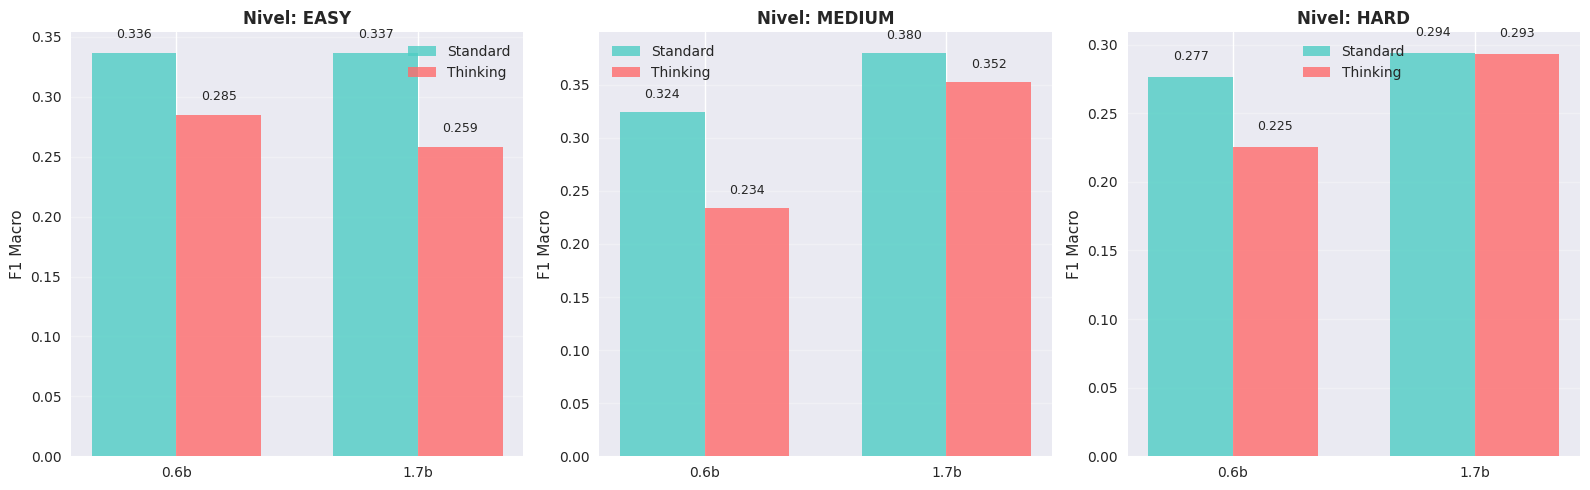

Grafico guardado en /home/eeguskiza/DEUSTO/multi-author-analysis/reports/11_f1_by_level.png


In [55]:
# Grafico de F1 Macro por nivel (3 subplots)

if len(results) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    levels = ['easy', 'medium', 'hard']
    model_labels = ['0.6b', '1.7b']
    x = np.arange(len(model_labels))
    width = 0.35
    
    for idx, level in enumerate(levels):
        ax = axes[idx]
        
        # Extraigo F1 para este nivel
        f1_standard = []
        f1_thinking = []
        
        for model in MODELS:
            std_key = f"{model}_standard"
            think_key = f"{model}_thinking"
            
            f1_std = results_by_level.get(std_key, {}).get(level, {}).get('f1_macro', 0)
            f1_think = results_by_level.get(think_key, {}).get(level, {}).get('f1_macro', 0)
            
            f1_standard.append(f1_std)
            f1_thinking.append(f1_think)
        
        # Creo barras
        bars1 = ax.bar(x - width/2, f1_standard, width, label='Standard', color='#4ECDC4', alpha=0.8)
        bars2 = ax.bar(x + width/2, f1_thinking, width, label='Thinking', color='#FF6B6B', alpha=0.8)
        
        ax.set_ylabel('F1 Macro', fontsize=11)
        ax.set_title(f'Nivel: {level.upper()}', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_labels)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        # Valores en barras
        for bar in bars1 + bars2:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / '11_f1_by_level.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Grafico guardado en {REPORTS_DIR / '11_f1_by_level.png'}")
else:
    print("Necesito al menos 2 resultados para crear el grafico.")

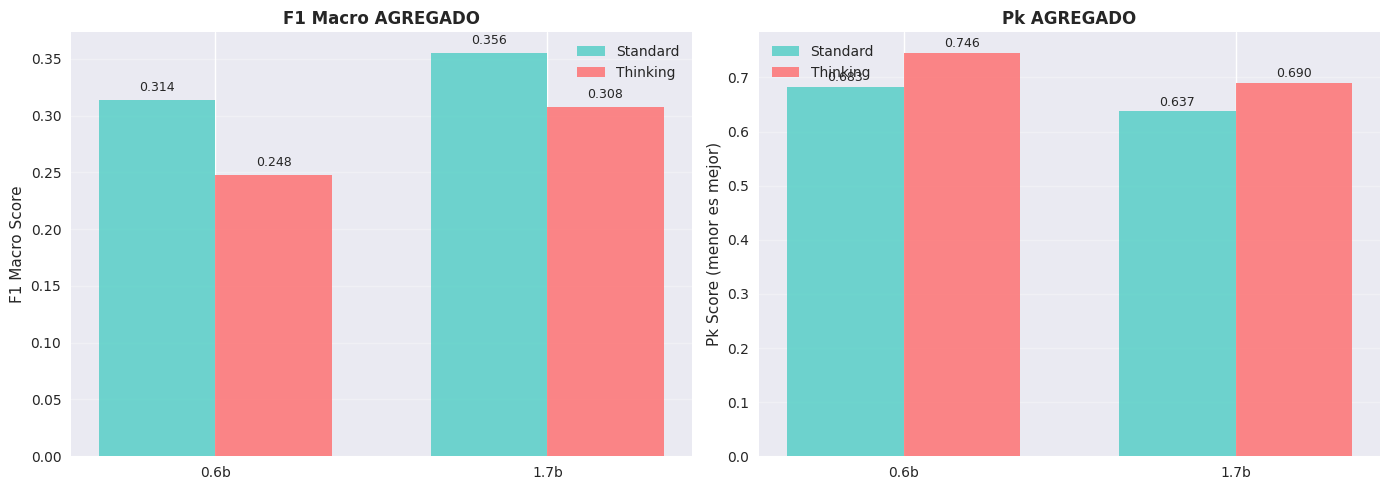

Grafico guardado en /home/eeguskiza/DEUSTO/multi-author-analysis/reports/11_mode_comparison_aggregated.png


In [57]:
# Graficos agregados: F1 y Pk

if len(results) >= 2:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    models_data = {'qwen3:0.6b': {}, 'qwen3:1.7b': {}}
    
    for model_name, result in results.items():
        parts = model_name.rsplit('_', 1)
        model = parts[0]
        mode = parts[1]
        
        if model in models_data:
            models_data[model][mode] = result['metrics']
    
    model_labels = ['0.6b', '1.7b']
    x = np.arange(len(model_labels))
    width = 0.35
    
    f1_standard = [models_data['qwen3:0.6b'].get('standard', {}).get('f1_macro', 0),
                   models_data['qwen3:1.7b'].get('standard', {}).get('f1_macro', 0)]
    f1_thinking = [models_data['qwen3:0.6b'].get('thinking', {}).get('f1_macro', 0),
                   models_data['qwen3:1.7b'].get('thinking', {}).get('f1_macro', 0)]
    
    pk_standard = [models_data['qwen3:0.6b'].get('standard', {}).get('pk', 0),
                   models_data['qwen3:1.7b'].get('standard', {}).get('pk', 0)]
    pk_thinking = [models_data['qwen3:0.6b'].get('thinking', {}).get('pk', 0),
                   models_data['qwen3:1.7b'].get('thinking', {}).get('pk', 0)]
    
    # Grafico 1: F1 Macro
    bars1_std = ax1.bar(x - width/2, f1_standard, width, label='Standard', color='#4ECDC4', alpha=0.8)
    bars1_think = ax1.bar(x + width/2, f1_thinking, width, label='Thinking', color='#FF6B6B', alpha=0.8)
    
    ax1.set_ylabel('F1 Macro Score', fontsize=11)
    ax1.set_title('F1 Macro AGREGADO', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_labels)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    for bar in bars1_std + bars1_think:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Grafico 2: Pk
    bars2_std = ax2.bar(x - width/2, pk_standard, width, label='Standard', color='#4ECDC4', alpha=0.8)
    bars2_think = ax2.bar(x + width/2, pk_thinking, width, label='Thinking', color='#FF6B6B', alpha=0.8)
    
    ax2.set_ylabel('Pk Score (menor es mejor)', fontsize=11)
    ax2.set_title('Pk AGREGADO', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_labels)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    for bar in bars2_std + bars2_think:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / '11_mode_comparison_aggregated.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Grafico guardado en {REPORTS_DIR / '11_mode_comparison_aggregated.png'}")
else:
    print("Necesito al menos 2 resultados para crear el grafico.")

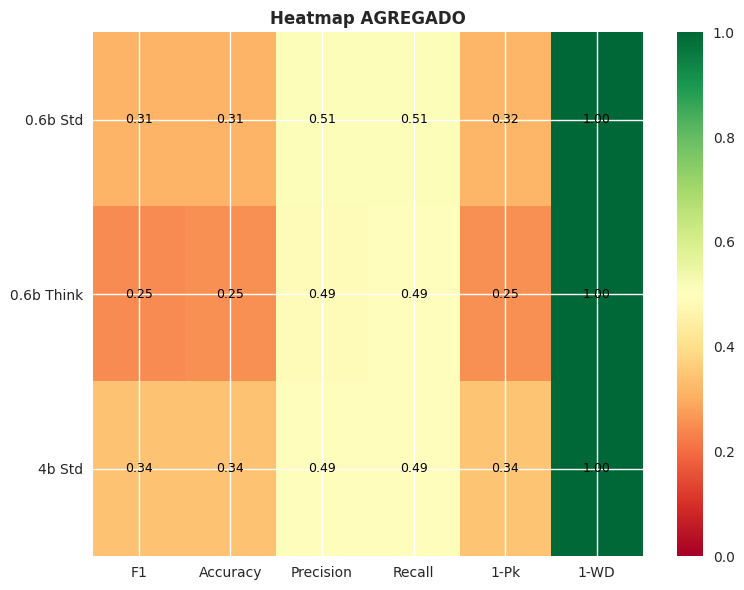

Heatmap guardado en /home/eeguskiza/DEUSTO/multi-author-analysis/reports/11_metrics_heatmap_aggregated.png


In [ ]:
# Heatmap de metricas agregadas

if results:
    metrics_data = []
    index_labels = []
    
    for model_name in sorted(results.keys()):
        result = results[model_name]
        parts = model_name.rsplit('_', 1)
        model = parts[0].replace('qwen3:', '')
        mode = "Std" if parts[1] == 'standard' else "Think"
        index_labels.append(f"{model} {mode}")
        
        m = result['metrics']
        metrics_data.append([
            m['f1_macro'],
            m['accuracy'],
            m['precision_macro'],
            m['recall_macro'],
            1 - m['pk'],
            1 - m['windowdiff']
        ])
    
    metrics_df = pd.DataFrame(
        metrics_data,
        index=index_labels,
        columns=['F1', 'Accuracy', 'Precision', 'Recall', '1-Pk', '1-WD']
    )
    
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(metrics_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    ax.set_xticks(np.arange(len(metrics_df.columns)))
    ax.set_yticks(np.arange(len(metrics_df.index)))
    ax.set_xticklabels(metrics_df.columns)
    ax.set_yticklabels(metrics_df.index)
    
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    
    for i in range(len(metrics_df.index)):
        for j in range(len(metrics_df.columns)):
            text = ax.text(j, i, f'{metrics_df.values[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=9)
    
    ax.set_title('Heatmap AGREGADO', fontweight='bold', fontsize=12)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / '11_metrics_heatmap_aggregated.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Heatmap guardado en {REPORTS_DIR / '11_metrics_heatmap_aggregated.png'}")

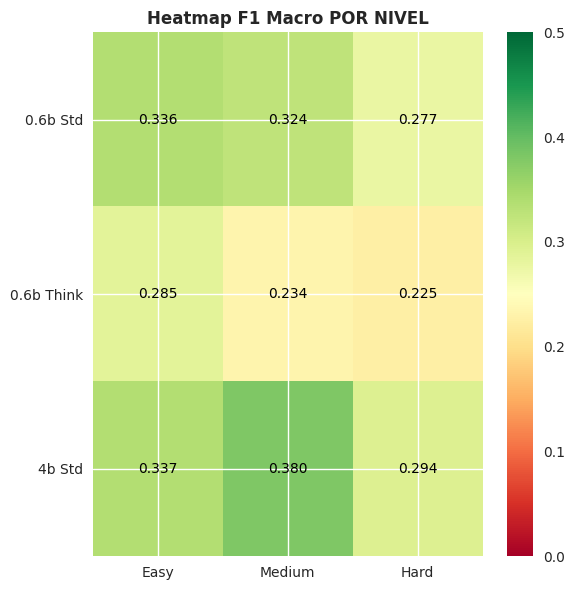

Heatmap guardado en /home/eeguskiza/DEUSTO/multi-author-analysis/reports/11_f1_heatmap_by_level.png


In [ ]:
# Heatmap de F1 por nivel

if results_by_level:
    f1_by_level_data = []
    config_labels = []
    
    for model_name in sorted(results_by_level.keys()):
        parts = model_name.rsplit('_', 1)
        model = parts[0].replace('qwen3:', '')
        mode = "Std" if parts[1] == 'standard' else "Think"
        config_labels.append(f"{model} {mode}")
        
        levels_data = results_by_level[model_name]
        f1_by_level_data.append([
            levels_data.get('easy', {}).get('f1_macro', 0),
            levels_data.get('medium', {}).get('f1_macro', 0),
            levels_data.get('hard', {}).get('f1_macro', 0),
        ])
    
    f1_level_df = pd.DataFrame(
        f1_by_level_data,
        index=config_labels,
        columns=['Easy', 'Medium', 'Hard']
    )
    
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(f1_level_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=max(0.5, f1_level_df.values.max()))
    
    ax.set_xticks(np.arange(len(f1_level_df.columns)))
    ax.set_yticks(np.arange(len(f1_level_df.index)))
    ax.set_xticklabels(f1_level_df.columns)
    ax.set_yticklabels(f1_level_df.index)
    
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    
    for i in range(len(f1_level_df.index)):
        for j in range(len(f1_level_df.columns)):
            text = ax.text(j, i, f'{f1_level_df.values[i, j]:.3f}',
                          ha="center", va="center", color="black", fontsize=10)
    
    ax.set_title('Heatmap F1 Macro POR NIVEL', fontweight='bold', fontsize=12)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / '11_f1_heatmap_by_level.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Heatmap guardado en {REPORTS_DIR / '11_f1_heatmap_by_level.png'}")

## 7. Guardado de resultados finales

In [54]:
# Guardo las metricas finales: agregadas + por nivel

def convert_numpy_types(obj):
    """Convierte tipos numpy a tipos nativos de Python para JSON."""
    import numpy as np
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(item) for item in obj]
    else:
        return obj

metrics_to_save = {}

for model_name, result in results.items():
    metrics_to_save[model_name] = {
        'metrics_aggregated': convert_numpy_types(result['metrics']),
        'metrics_by_level': convert_numpy_types(results_by_level[model_name]),
        'classification_report': result['classification_report']
    }

# Metadatos
metrics_to_save['_metadata'] = {
    'models': MODELS,
    'n_eval': int(N_EVAL),
    'n_shots': int(N_SHOTS),
    'seed': int(SEED),
    'modes': ['standard', 'thinking'],
    'eval_subset_distribution': {k: int(v) for k, v in eval_subset['y'].value_counts().to_dict().items()},
    'eval_subset_by_level': {
        level: int(len(eval_subset[eval_subset['level'] == level]))
        for level in ['easy', 'medium', 'hard']
    },
    'note': 'Evaluacion ICL comparando 2 modelos (qwen3:0.6b y qwen3:1.7b) en 2 modos cada uno (standard vs thinking con CoT + contexto extendido). Incluye metricas agregadas y desglosadas por nivel de dificultad.'
}

with open(REPORTS_DIR / "11_icl_metrics_final.json", "w") as f:
    json.dump(metrics_to_save, f, indent=2)

print(f"Metricas finales guardadas en {REPORTS_DIR / '11_icl_metrics_final.json'}")
print("  - Incluye metricas agregadas")
print("  - Incluye metricas por nivel (easy, medium, hard)")

Metricas finales guardadas en /home/eeguskiza/DEUSTO/multi-author-analysis/reports/11_icl_metrics_final.json
  - Incluye metricas agregadas
  - Incluye metricas por nivel (easy, medium, hard)


In [ ]:
# Guardo las predicciones en formato .npz

for model_name, result in results.items():
    filename = f"icl_{model_name.replace(':', '_')}_val.npz"
    
    np.savez_compressed(
        PREDICTIONS_DIR / filename,
        predictions=result['predictions'],
        y_true=eval_subset['y'].to_numpy(),
        doc_ids=eval_subset['doc_id'].to_numpy(),
        boundary_ids=eval_subset['boundary_id'].to_numpy(),
        levels=eval_subset['level'].to_numpy(),  # Incluyo niveles para analisis posterior
        responses_raw=np.array(result['responses_raw'], dtype=object)
    )
    
    print(f"Predicciones guardadas en {filename}")

print(f"\nTodas las predicciones guardadas en {PREDICTIONS_DIR}")

Predicciones guardadas en icl_qwen3_0.6b_standard_val.npz
Predicciones guardadas en icl_qwen3_0.6b_thinking_val.npz
Predicciones guardadas en icl_qwen3_4b_standard_val.npz

Todas las predicciones guardadas en /home/eeguskiza/DEUSTO/multi-author-analysis/data/processed/predictions
